<a href="https://colab.research.google.com/github/banotahira0915-bano/Colab--amlcodes/blob/main/Exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

===== MODEL PERFORMANCE =====

Ridge Regression:
R² Score : 0.575815742891368
RMSE     : 0.7455567442814782

Lasso Regression:
R² Score : 0.4813611325029077
RMSE     : 0.8243961598848469

===== COMPARISON =====
   Model  R² Score      RMSE
0  Ridge  0.575816  0.745557
1  Lasso  0.481361  0.824396


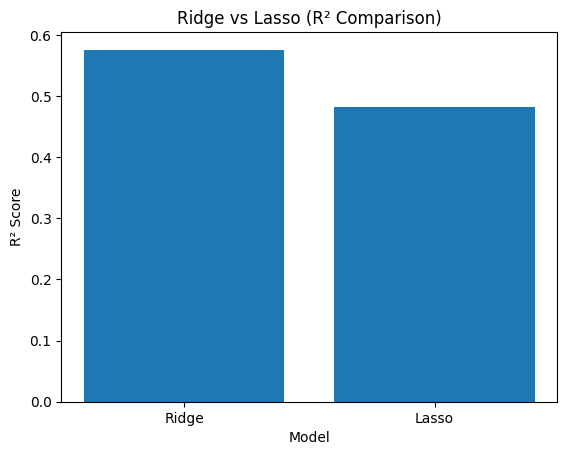

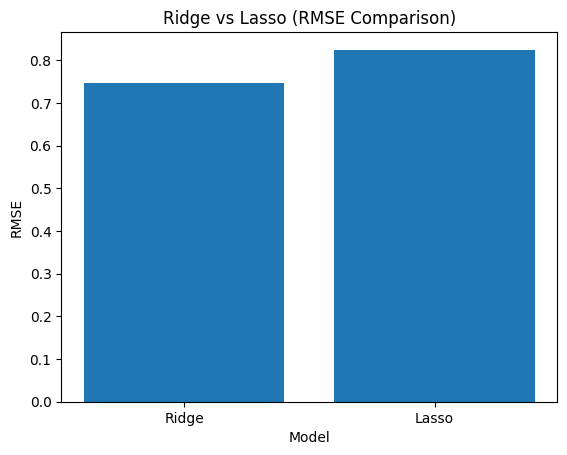


===== COEFFICIENT COMPARISON =====
      Feature  Ridge Coefficients  Lasso Coefficients
0      MedInc            0.854327            0.710598
1    HouseAge            0.122624            0.106453
2    AveRooms           -0.294210           -0.000000
3   AveBedrms            0.339008            0.000000
4  Population           -0.002282           -0.000000
5    AveOccup           -0.040833           -0.000000
6    Latitude           -0.896168           -0.011469
7   Longitude           -0.869071           -0.000000


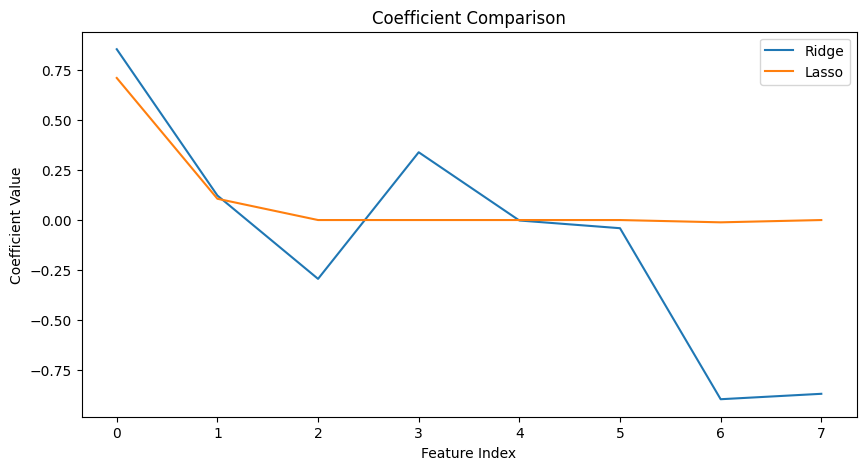

In [ ]:
# ================================
# 1. Import Libraries
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

# ================================
# 2. Load Multivariate Dataset
# ================================
data = fetch_california_housing()

X = data.data
y = data.target

# ================================
# 3. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 4. Feature Scaling (Important!)
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# 5. Train Ridge Regression
# ================================
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

# ================================
# 6. Train Lasso Regression
# ================================
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

# ================================
# 7. Evaluation Metrics
# ================================
def evaluate_model(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse

ridge_r2, ridge_rmse = evaluate_model(y_test, y_pred_ridge)
lasso_r2, lasso_rmse = evaluate_model(y_test, y_pred_lasso)

# ================================
# 8. Print Results
# ================================
print("===== MODEL PERFORMANCE =====\n")

print("Ridge Regression:")
print("R² Score :", ridge_r2)
print("RMSE     :", ridge_rmse)

print("\nLasso Regression:")
print("R² Score :", lasso_r2)
print("RMSE     :", lasso_rmse)

# ================================
# 9. Comparison Table
# ================================
results = pd.DataFrame({
    'Model': ['Ridge', 'Lasso'],
    'R² Score': [ridge_r2, lasso_r2],
    'RMSE': [ridge_rmse, lasso_rmse]
})

print("\n===== COMPARISON =====")
print(results)

# ================================
# 10. Plot Comparison
# ================================
plt.figure()
plt.bar(results['Model'], results['R² Score'])
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Ridge vs Lasso (R² Comparison)")
plt.show()

plt.figure()
plt.bar(results['Model'], results['RMSE'])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Ridge vs Lasso (RMSE Comparison)")
plt.show()

# ================================
# 11. Coefficient Comparison
# ================================
ridge_coef = ridge.coef_
lasso_coef = lasso.coef_

coef_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Ridge Coefficients': ridge_coef,
    'Lasso Coefficients': lasso_coef
})

print("\n===== COEFFICIENT COMPARISON =====")
print(coef_df)

# ================================
# 12. Visualization of Coefficients
# ================================
plt.figure(figsize=(10,5))
plt.plot(ridge_coef, label='Ridge')
plt.plot(lasso_coef, label='Lasso')
plt.legend()
plt.title("Coefficient Comparison")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.show()